In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("impactofai.csv")

In [3]:
df = df.drop(columns=[
    'Student_ID',
    'Primary_Use_Case',
    'Institutional_Policy',
    'Burnout_Risk_Level'
])

In [4]:
df.shape

(50000, 12)

In [5]:
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
0,Humanities,Senior,2.418,23.31,Beginner,1,True,8.13,5,6,2.393,86.44
1,Medical,Junior,3.821,1.12,Advanced,5,False,16.65,3,9,3.696,69.39
2,Business,Freshman,3.398,21.26,Beginner,2,False,10.35,5,9,3.499,73.93
3,Business,Senior,3.789,1.82,Intermediate,4,False,15.23,2,2,4.000,63.58
4,STEM,Sophomore,3.635,9.29,Advanced,4,False,12.55,4,4,3.798,100.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Prompt_Engineering_Skill    50000 non-null  object 
 5   Tool_Diversity              50000 non-null  int64  
 6   Paid_Subscription           50000 non-null  bool   
 7   Traditional_Study_Hours     50000 non-null  float64
 8   Perceived_AI_Dependency     50000 non-null  int64  
 9   Anxiety_Level_During_Exams  50000 non-null  int64  
 10  Post_Semester_GPA           50000 non-null  float64
 11  Skill_Retention_Score       50000 non-null  float64
dtypes: bool(1), float64(5), int64(3), object(3)
memory usage: 4.2+ MB


In [7]:
df.isnull().sum()

Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [10]:
df.corr(numeric_only=True)

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Pre_Semester_GPA,1.000000,-0.001084,-0.005671,-0.001027,-0.004620,0.000701,-0.000667,0.926781,0.099019
Weekly_GenAI_Hours,-0.001084,1.000000,0.008411,0.196943,-0.157368,0.665479,0.269080,-0.018600,-0.118099
Tool_Diversity,-0.005671,0.008411,1.000000,0.005803,0.003565,0.006019,0.003189,0.025265,0.196952
Paid_Subscription,-0.001027,0.196943,0.005803,1.000000,-0.035329,0.131033,0.065845,0.005528,-0.024083
Traditional_Study_Hours,-0.004620,-0.157368,0.003565,-0.035329,1.000000,-0.102625,-0.040935,0.137653,0.147565
Perceived_AI_Dependency,0.000701,0.665479,0.006019,0.131033,-0.102625,1.000000,0.307620,-0.014180,-0.084324
Anxiety_Level_During_Exams,-0.000667,0.269080,0.003189,0.065845,-0.040935,0.307620,1.000000,-0.015909,-0.041556
Post_Semester_GPA,0.926781,-0.018600,0.025265,0.005528,0.137653,-0.014180,-0.015909,1.000000,0.169616
Skill_Retention_Score,0.099019,-0.118099,0.196952,-0.024083,0.147565,-0.084324,-0.041556,0.169616,1.000000


In [11]:
df['change_in_gpa']=df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

In [12]:
df.corr(numeric_only=True)['Pre_Semester_GPA']

Pre_Semester_GPA              1.000000
Weekly_GenAI_Hours           -0.001084
Tool_Diversity               -0.005671
Paid_Subscription            -0.001027
Traditional_Study_Hours      -0.004620
Perceived_AI_Dependency       0.000701
Anxiety_Level_During_Exams   -0.000667
Post_Semester_GPA             0.926781
Skill_Retention_Score         0.099019
change_in_gpa                -0.104035
Name: Pre_Semester_GPA, dtype: float64

<Axes: ylabel='count'>

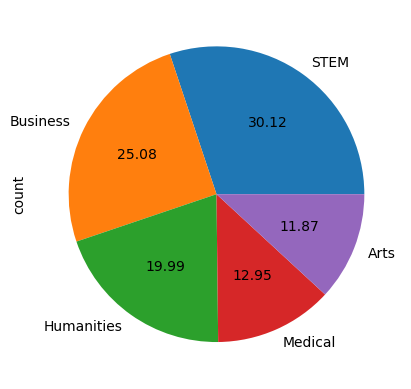

In [13]:
df['Major_Category'].value_counts().plot(kind='pie',autopct='%.2f')

#### STEM stands for Science, Technology, Engineering, and Mathematics.

#### melt()

Pre_Semester_GPA ─┐

                  ├──> Semester
                  
Post_Semester_GPA ┘


unke values ────────> GPA

id_vars → The column(s) that remain unchanged.

value_vars → The column(s) that you want to combine/reshape.

var_name → The name of the new column that will contain the original column names.

value_name → The name of the new column that will contain the actual values.

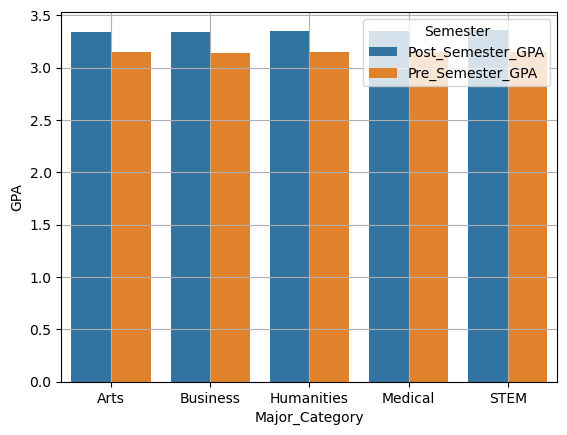

In [16]:
df_melt = df.melt(
    id_vars='Major_Category',
    value_vars=['Pre_Semester_GPA', 'Post_Semester_GPA'],
    var_name='Semester',
    value_name='GPA'
)

df_avg = df_melt.groupby(
    ['Major_Category', 'Semester'],
    as_index=False
)['GPA'].mean()

sns.barplot(
    data=df_avg,
    x='Major_Category',
    y='GPA',
    hue='Semester'
)
plt.grid()

In [15]:
df_avg

,Major_Category,Semester,GPA
0,Arts,Post_Semester_GPA,3.343688
1,Arts,Pre_Semester_GPA,3.146786
2,Business,Post_Semester_GPA,3.336085
3,Business,Pre_Semester_GPA,3.141760
4,Humanities,Post_Semester_GPA,3.345825
5,Humanities,Pre_Semester_GPA,3.147850
6,Medical,Post_Semester_GPA,3.353168
7,Medical,Pre_Semester_GPA,3.151769
8,STEM,Post_Semester_GPA,3.363154
9,STEM,Pre_Semester_GPA,3.145852
